## Тема:
«Исследование и сравнение методов понижения размерности и кластеризации на реальном высокоразмерном датасете (из области по выбору: биоинформатика, тексты, изображения, графы) с анализом устойчивости и интерпретируемости полученных кластеров».[7][5]

## Основные требования к проекту:

Выбор и обоснование одного или двух реальных высокоразмерных датасетов (например, single‑cell RNA‑seq, embedding‑представления текстов, feature‑описания изображений).[2][5]
Построение и сравнение нескольких пайплайнов «DR → кластеризация» (минимум 3 DR‑метода и 3 алгоритма кластеризации) с оценкой качества, устойчивости и практической интерпретации кластеров.[4][12][7]

## Считываем датасет AG News

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score,
                             adjusted_mutual_info_score, homogeneity_completeness_v_measure)
import umap
import trimap

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = load_dataset('ag_news', cache_dir='data/')['test'] #
df.shape

(7600, 2)

In [3]:
labels, counts = np.unique(list(df['label']), return_counts=True)
labels, counts

(array([0, 1, 2, 3]), array([1900, 1900, 1900, 1900]))

## Преобразуем набор текстов в вектора эмбеддингов

In [4]:
vectorizer = TfidfVectorizer()
df_vectors = vectorizer.fit_transform(df['text'])

In [5]:
df_vectors.shape

(7600, 21853)

## Модель KMeans

In [6]:
k_means = KMeans(n_clusters=len(labels), random_state=42)

pred_test_labels = k_means.fit_predict(df_vectors)
true_test_labels = np.array(df['label'])

Используем метрику normalized_mutual_info_score, которая инвариантна относительно перестановок, поэтому проблем с тем, что модель класс 0 предсказывает как класс 1 не будет, метрика это учитывает.

In [7]:
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(true_test_labels, pred_test_labels)

print(f"NMI: {nmi:.3f}")

NMI: 0.213


# PCA для сравнения исходных меток и предсказанных меток

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

df_vectors_pca = pca.fit_transform(df_vectors)
df_vectors_pca.shape

(7600, 2)

In [9]:
pca.explained_variance_ratio_

array([0.00559467, 0.0036673 ])

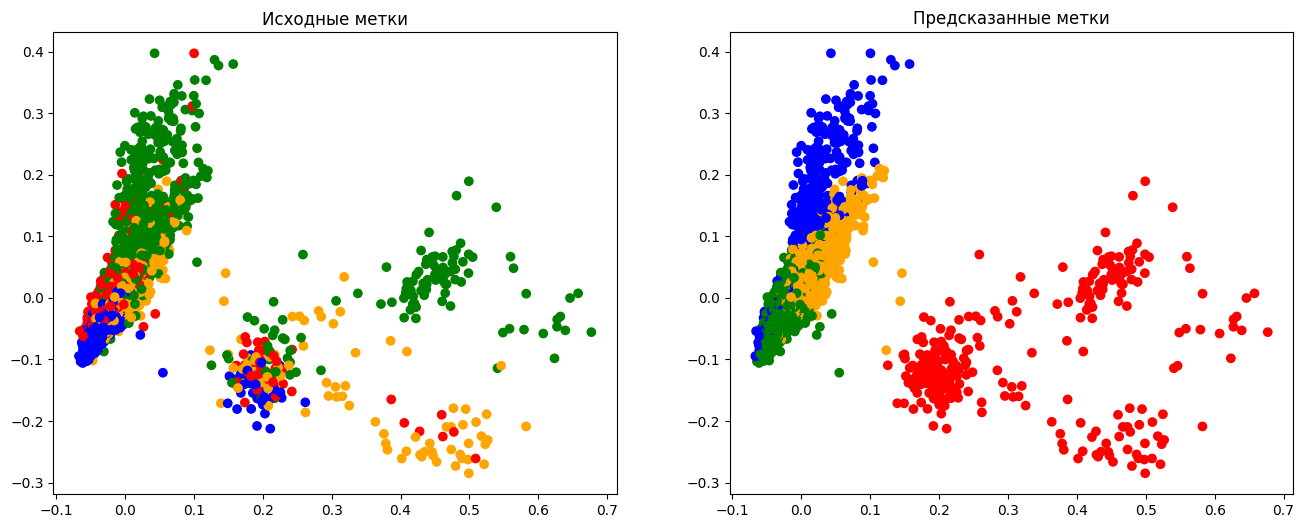

In [10]:
colors_dict = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'orange'
}

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.title('Исходные метки')
plt.scatter(df_vectors_pca[:, 0], df_vectors_pca[:, 1], c=[colors_dict[x] for x in df['label']])

plt.subplot(1, 2, 2)
plt.title('Предсказанные метки')
plt.scatter(df_vectors_pca[:, 0], df_vectors_pca[:, 1], c=[colors_dict[x] for x in pred_test_labels])
plt.show()

# Общий пайплайн для понижения размерности и кластеризации

### Методы DM: PCA, t-SNE, UMAP, TriMAP

In [11]:
def run_pca(X, n_components=2, random_state=42):
    pca = PCA(
        n_components=n_components
    )
    return pca.fit_transform(X)

def run_tsne(X, n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000):
    tsne = TSNE(
        random_state=random_state,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_components=n_components
    )
    return tsne.fit_transform(X)

def run_umap(X, n_components=2, random_state=42, n_neighbors=15, min_dist=0.1):
    Umap = umap.UMAP(
        n_components=n_components,
        random_state=random_state,
        n_neighbors=n_neighbors,
        min_dist=min_dist
    )
    return Umap.fit_transform(X)

def run_trimap(X, n_components=2, n_inliers=10, n_outliers=5, random_state=None):
    Trimap = trimap.TRIMAP(
        n_dims=n_components,
        n_inliers=n_inliers,
        n_outliers=n_outliers
    )
    return Trimap.fit_transform(X.toarray())

### Методы кластеризации: KMeans, AgglomerativeClustering, DBSCAN, Birch

In [23]:
def run_kmeans(X, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters, 
                    n_init=10)
    return kmeans.fit_predict(X)

def run_agglomerative(X, n_clusters=10, linkage='ward'):
    agg = AgglomerativeClustering(n_clusters=n_clusters, 
                                    linkage=linkage)
    return agg.fit_predict(X)

def run_dbscan(X, eps=0.1, min_samples=25, n_clusters=None):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    return dbscan.fit_predict(X)

def run_birch(X, n_clusters=10):
    birch = Birch(n_clusters=n_clusters, threshold=0.1) #
    return birch.fit_predict(X)

def run_clusterization_method(df, clusterization_method, n_clusters):
    pred_labels_bootstrap = np.array(clusterization_method(df, n_clusters=n_clusters))
    pred_labels_bootstrap[~np.isin(pred_labels_bootstrap, np.arange(n_clusters))] = 0
    return pred_labels_bootstrap

### Метрики для оценки качества: Silhouette, Calinski Harabasz, Davies Bouldin, ARI, AMI, Homogeneity, Completeness и V Measure

In [13]:
def compute_all_metrics(X, labels, y_true=None):
    if len(np.unique(labels)) < 2:
        return {}
    
    internal_metrics = {
        'silhouette': silhouette_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels)
    }
    
    external_metrics = None
    if y_true is not None:
        external_metrics = {
            'ari': adjusted_rand_score(y_true, labels),
            'ami': adjusted_mutual_info_score(y_true, labels),
            'homogeneity': homogeneity_completeness_v_measure(y_true, labels)[0],
            'completeness': homogeneity_completeness_v_measure(y_true, labels)[1],
            'v_measure': homogeneity_completeness_v_measure(y_true, labels)[2]
        }
    
    return {
        'internal_metrics': internal_metrics,
        'external_metrics': external_metrics
        }

## Общий пайплайн для сравнения методов

In [24]:
def make_bootstrap_samples(X, n_samples):
    indices = np.random.randint(0, len(X), (n_samples, len(X)))
    return X[indices]

def calculate_metrics(df, pred_labels, y_true, decomposer_name, clusterization_name):
    metrics = compute_all_metrics(df, pred_labels, y_true=y_true)
    current_metrics = pd.DataFrame({
        'Decomposer': [decomposer_name],
        'Clusterization': [clusterization_name]
    })    
    for metric_type in metrics.keys():
        for metric in metrics[metric_type].keys():
            current_metrics[metric] = metrics[metric_type][metric]
    return current_metrics

def make_stability_test(df, n_samples, clusterization_method, n_clusters):
    df_bootstrap = make_bootstrap_samples(df, n_samples)
    all_pred_labels_bootstrap = []
    for i in range(df_bootstrap.shape[0]):
        all_pred_labels_bootstrap += [run_clusterization_method(df_bootstrap[i], clusterization_method, n_clusters)]    
    ari = []
    for i, first_labels in enumerate(all_pred_labels_bootstrap):
        for j, second_labels in enumerate(all_pred_labels_bootstrap):
            if i == j:
                continue
            ari += [adjusted_rand_score(first_labels, second_labels)]
    return np.mean(ari)

def full_pipeline(df, n_components=None, n_clusters=None, random_state=42, main_metric='calinski_harabasz', ascending_metric=False, n_samples=10):
    if (not n_components) or (n_components <= 0):
        print('n_components must be an int number > 0!')
        return
    
    if (not n_clusters) or (n_clusters <= 0):
        print('n_classes must be an int number > 0!')
        return
    
    if isinstance(df, str):
        df_raw = load_dataset(df, cache_dir="data/")['test']
        
        vectorizer = TfidfVectorizer()
        df = vectorizer.fit_transform(df_raw['text'])

        colors_dict = {
            0: 'red',
            1: 'blue',
            2: 'green',
            3: 'orange'
        }

    decomposer_methods = [run_pca, run_tsne, run_umap, run_trimap]
    decomposer_names = ['PCA', 't-SNE', 'UMAP', 'TriMAP']
    
    clusterization_methods = [run_kmeans, run_agglomerative, run_dbscan, run_birch] #
    clusterization_names = ['KMeans', 'AgglomerativeClustering','DBSCAN', 'Birch'] #
    
    idx = 1
    plt.figure(figsize=(16, 16))
    plt.suptitle(
        f'Сравнение разных методов кластеризации ({len(clusterization_methods)}шт) на разных DR-представлениях ({len(decomposer_methods)}шт)', 
        fontsize=16, 
        y=0.92
    )

    all_metrics = pd.DataFrame()
    stability_results = pd.DataFrame()

    for decomposer_method, decomposer_name in zip(decomposer_methods, decomposer_names):
        for clusterization_method, clusterization_name in zip(clusterization_methods, clusterization_names):
            
            df_decomposed = decomposer_method(df, n_components=n_components, random_state=random_state)            
            pred_labels = run_clusterization_method(df_decomposed, clusterization_method, n_clusters)
            
            all_metrics = pd.concat([
                all_metrics, 
                calculate_metrics(df_decomposed, pred_labels, df_raw['label'], decomposer_name, clusterization_name)
            ], ignore_index=True)
            
            stability_results = pd.concat([stability_results, pd.DataFrame({
                'Decomposer': [decomposer_name],
                'Clusterization': [clusterization_name],
                'ARI': [make_stability_test(df_decomposed, n_samples, clusterization_method, n_clusters)]
            })], ignore_index=True)
            
            plt.subplot(len(decomposer_methods), len(clusterization_methods), idx)
            plt.title(f'{clusterization_name}. {decomposer_name}')
            plt.scatter(df_decomposed[:, 0], df_decomposed[:, 1], c=[colors_dict[x] for x in pred_labels])    
            idx += 1
    plt.show()
    return all_metrics.sort_values(by=main_metric, ascending=ascending_metric, ignore_index=True), stability_results.sort_values(by='ARI', ignore_index=True, key=lambda x: abs(x))

# Визуализация различных DR методов и методов кластеризации

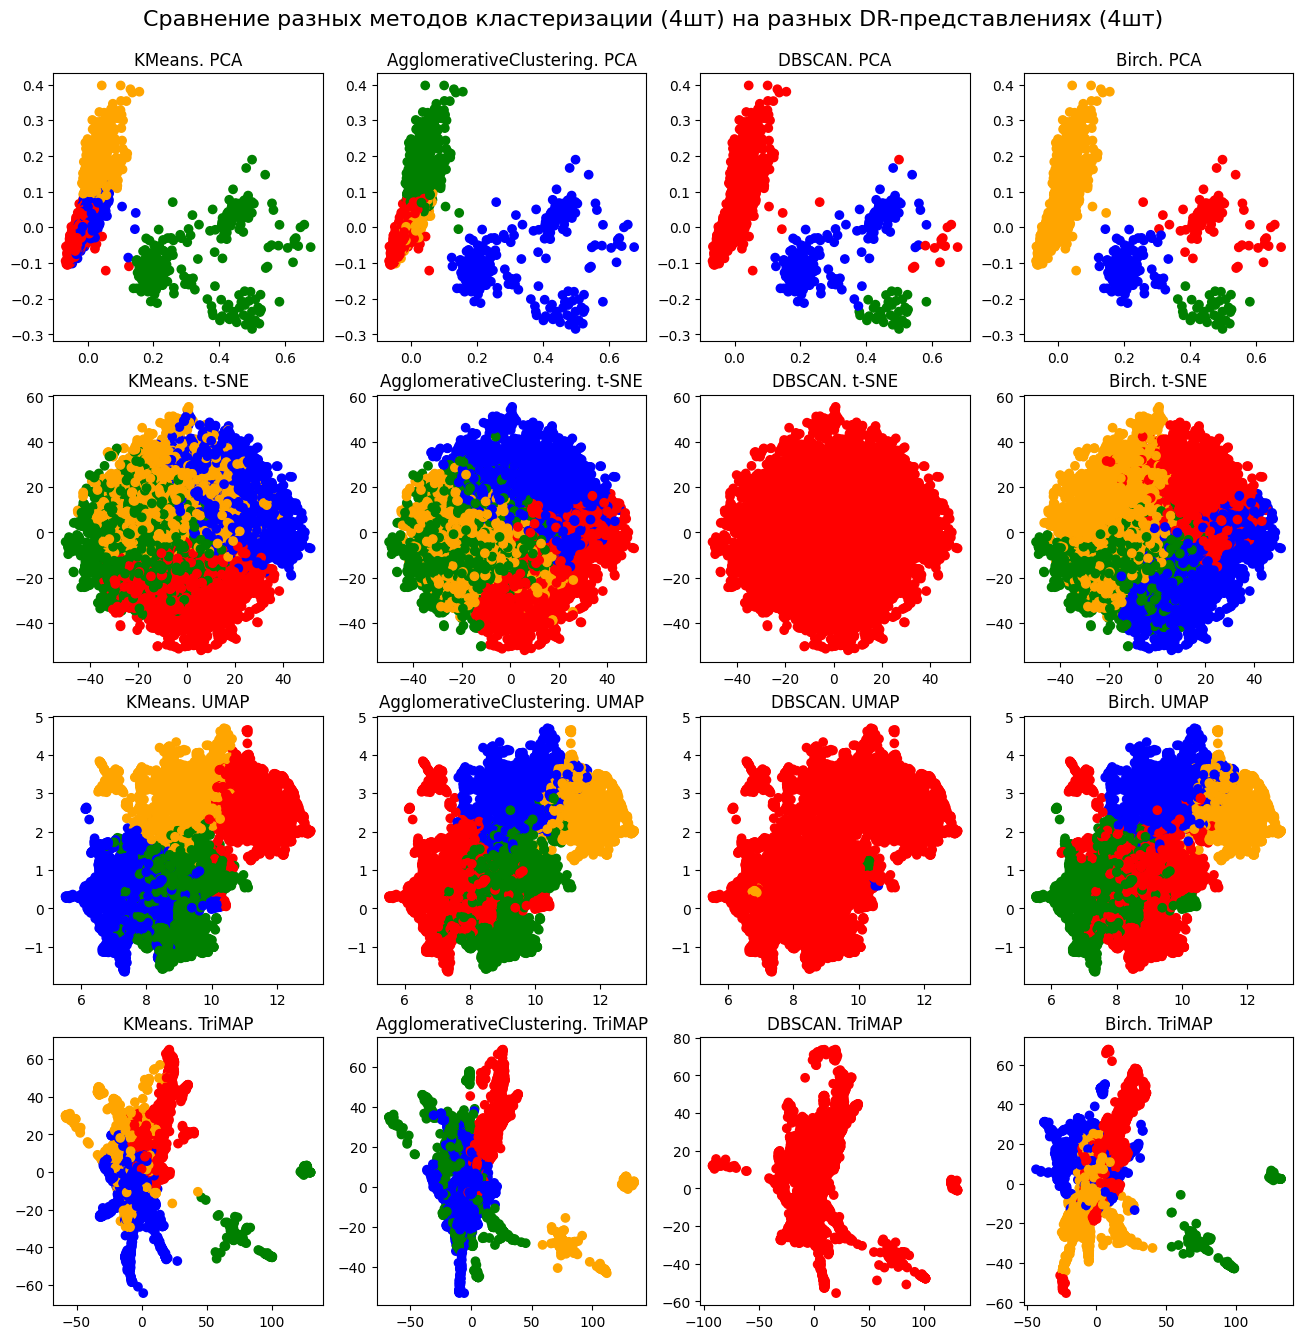

In [25]:
all_metrics, stability_results = full_pipeline('ag_news', n_components=3, n_clusters=len(labels), random_state=42)

# Оценка качества с помощью метрик (основная метрика - Calinski Harabasz)

In [26]:
all_metrics

,Decomposer,Clusterization,silhouette,calinski_harabasz,davies_bouldin,ari,ami,homogeneity,completeness,v_measure
0,UMAP,KMeans,0.382983,5705.228526,1.000101,0.493880,0.467791,0.467006,0.469036,0.468019
1,PCA,KMeans,0.403249,5321.128296,0.794848,0.205977,0.234845,0.201457,0.282599,0.235227
2,UMAP,AgglomerativeClustering,0.356787,5233.546598,1.018636,0.479750,0.455662,0.452257,0.459595,0.455896
3,UMAP,Birch,0.353295,5113.549096,1.016593,0.465265,0.449665,0.444895,0.455024,0.449903
4,PCA,AgglomerativeClustering,0.382650,4591.333427,0.788972,0.109266,0.193677,0.159447,0.247990,0.194097
5,TriMAP,KMeans,0.363961,3892.326511,0.929011,0.199271,0.254144,0.231816,0.282091,0.254494
6,TriMAP,Birch,0.333462,3212.905681,1.024237,0.160132,0.212219,0.191160,0.239441,0.212594
7,TriMAP,AgglomerativeClustering,0.369620,3170.161766,1.024923,0.095230,0.154119,0.137250,0.176778,0.154526
8,t-SNE,KMeans,0.256085,2926.955497,1.244822,0.304269,0.305788,0.305506,0.306666,0.306085
9,t-SNE,AgglomerativeClustering,0.205758,2382.153493,1.337634,0.273797,0.287210,0.285776,0.289278,0.287517


### Среди всех методов наилучшее качество имеет KMeans с уменьшением размерности через UMAP.

# Оценка устойчивости с помощью bootstrap и метрики AMI

In [27]:
stability_results

,Decomposer,Clusterization,ARI
0,UMAP,AgglomerativeClustering,0.000017
1,t-SNE,KMeans,-0.000024
2,UMAP,KMeans,0.000066
3,t-SNE,Birch,0.000127
4,UMAP,Birch,-0.000162
5,t-SNE,AgglomerativeClustering,0.000226
6,PCA,KMeans,-0.000229
7,TriMAP,KMeans,-0.000250
8,PCA,DBSCAN,-0.000276
9,TriMAP,AgglomerativeClustering,-0.000317


### Так как все методы имеют ARI около 0, то это означает, что все методы являются нестабильными, так как ARI~0 означает СЛУЧАЙНУЮ разметку классов (то есть для разных запусков разметки совсем не похожи). Для DBSCAN t-SNE и TriMAP имею ARI=1.0, что означает идентичные метки (это только потому, что эти методы выделяют только 1 кластер на всех данных).